# Merge tract-level predictions to tract geometries

Reads the `predictions_by_tract_{year}.parquet` files written by `generate_predictions`
(one row per GEOID per year: `Rel_Score`, `predicted_value`, `predicted_value_std`),
joins them to the tract polygons in `data/processed/tract_splits.feather`, and writes a
single GeoParquet for QGIS. Long format (one row per GEOID x year) so QGIS can filter /
categorize by `year` directly.

In [50]:
import geopandas as gpd
import pandas as pd

from src.utils.paths import PROCESSED_DATA_DIR, RESULTS_DIR

In [51]:
# --- config: point this at the run directory holding predictions_by_tract_{year}.parquet ---
SAVENAME = "run_20260710"
run_dir = RESULTS_DIR / SAVENAME

tract_files = sorted(run_dir.glob("predictions_by_tract_*.parquet"))
years = [int(p.stem.rsplit("_", 1)[1]) for p in tract_files]
print(f"Found {len(tract_files)} year(s) in {run_dir}: {years}")

Found 10 year(s) in C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\run_20260710: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


In [52]:
def _norm_geoid(x) -> str:
    return str(int(x)).zfill(11)


frames = []
for path, year in zip(tract_files, years):
    df = pd.read_parquet(path)
    df["GEOID"] = df["GEOID"].apply(_norm_geoid)
    df["year"] = year
    frames.append(df)

preds_long = pd.concat(frames, ignore_index=True)
preds_long.head()

,GEOID,Rel_Score,predicted_value,predicted_value_std,year
0,04013040514,-0.296418,-0.153514,0.537319,2010
1,04013040522,-0.511968,0.446684,0.405014,2010
2,04013040529,-0.100162,0.475710,0.444552,2010
3,04013040537,0.802125,0.819048,0.465002,2010
4,04013040541,-0.563930,-0.832318,0.620725,2010


In [53]:
tracts = gpd.read_feather(PROCESSED_DATA_DIR / "tract_splits.feather")
tracts = tracts.rename(columns={"GEOID": "GEOID_geom"})
tracts["GEOID"] = tracts["GEOID_geom"].astype(str).str.zfill(11)
tracts = tracts.drop(columns="GEOID_geom")
tracts.head()

,geometry,type,GEOID
0,"POLYGON ((804815.502 1149935.329, 804804.84 11...",train,01007010001
1,"POLYGON ((814129.699 1162957.549, 814825.418 1...",train,01007010005
2,"POLYGON ((819848.932 1164943.829, 819995.709 1...",train,01007010006
3,"POLYGON ((816634.86 1122757.442, 816877.291 11...",train,01007010007
4,"POLYGON ((821799.031 1138178.726, 821833.458 1...",train,01007010008


In [54]:
merged = tracts.merge(preds_long, on="GEOID", how="inner")
merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=tracts.crs)

n_unmatched = preds_long["GEOID"].nunique() - merged["GEOID"].nunique()
print(f"{len(merged):,} tract-year rows across {merged['GEOID'].nunique():,} tracts "
      f"({n_unmatched:,} predicted GEOIDs had no geometry match)")
merged.head()

28,597 tract-year rows across 5,994 tracts (0 predicted GEOIDs had no geometry match)


,geometry,type,GEOID,Rel_Score,predicted_value,predicted_value_std,year
0,"POLYGON ((-1498324.959 1308692.093, -1496602.1...",test,04013040514,-0.296418,-0.153514,0.537319,2010
1,"POLYGON ((-1498324.959 1308692.093, -1496602.1...",test,04013040514,-0.608338,0.438793,0.425180,2013
2,"POLYGON ((-1498324.959 1308692.093, -1496602.1...",test,04013040514,-0.836606,0.179512,0.509339,2015
3,"POLYGON ((-1498324.959 1308692.093, -1496602.1...",test,04013040514,-0.511510,0.141798,0.489012,2017
4,"POLYGON ((-1498324.959 1308692.093, -1496602.1...",test,04013040514,-0.472860,0.073948,0.522996,2019


In [55]:
out_path = run_dir / "tract_predictions_for_qgis.parquet"
merged.to_parquet(out_path)
print(f"Wrote {out_path}")

Wrote C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\run_20260710\tract_predictions_for_qgis.parquet


## Per-city Spearman correlation

Attaches `cbsa_code` (via the national ACS panel, joined on `GEOID`) to the tract-level
predictions, then reuses the paper's canonical within-city metric
(`src.utils.metrics.within_city_cells` / `weighted_within_spearman` — same functions the
training-time validation loop and `evaluation.py` use) to compute one Spearman(`predicted_value`,
`Rel_Score`) per (CBSA, year) cell. Cells with fewer than `min_bld` tracts, or without rank
variation in either column, are dropped as noise.

In [56]:
from src.utils.metrics import within_city_cells, weighted_within_spearman

panel = pd.read_feather(
    PROCESSED_DATA_DIR / "us_metros_panel_2011_2023.feather",
    columns=["geoid_2023", "cbsa_code"],
).rename(columns={"geoid_2023": "GEOID"})
panel["GEOID"] = panel["GEOID"].astype(str).str.zfill(11)
panel["cbsa_code"] = panel["cbsa_code"].astype(str)
panel = panel.drop_duplicates("GEOID")

cbsa_titles = pd.read_feather(
    PROCESSED_DATA_DIR / "cbsa_splits.feather",
    columns=["cbsa_code", "cbsa_title", "population", "bracket"],
)
cbsa_titles["cbsa_code"] = cbsa_titles["cbsa_code"].astype(str)

city_preds = preds_long.merge(panel, on="GEOID", how="left")
n_unmatched = city_preds["cbsa_code"].isna().sum()
if n_unmatched:
    print(f"{n_unmatched:,} / {len(city_preds):,} tract-year rows had no CBSA match — dropped")
city_preds = city_preds.dropna(subset=["cbsa_code"])

In [57]:
cells_df = city_preds.rename(
    columns={"predicted_value": "pred", "Rel_Score": "label", "cbsa_code": "cbsa"}
)
cells = within_city_cells(cells_df, min_bld=5)
cells = cells.merge(cbsa_titles, left_on="cbsa", right_on="cbsa_code", how="left").drop(
    columns="cbsa_code"
)
cells = cells[["cbsa", "cbsa_title", "population", "bracket", "year", "n", "rho"]].sort_values(
    ["year", "rho"], ascending=[True, False]
)

headline = weighted_within_spearman(within_city_cells(cells_df, min_bld=5))
print(f"Size-weighted within-city Spearman: {headline.get('within_spearman'):.3f} "
      f"({headline.get('within_cells')} cells, n={headline.get('within_n'):,} tracts)")

out_csv = run_dir / "per_city_spearman.csv"
cells.to_csv(out_csv, index=False)
print(f"Wrote {out_csv}")
cells

Size-weighted within-city Spearman: 0.629 (184 cells, n=28,558 tracts)
Wrote C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\run_20260710\per_city_spearman.csv


,cbsa,cbsa_title,population,bracket,year,n,rho
119,36420,"Oklahoma City, OK",1445122,large,2010,100,0.868648
14,12940,"Baton Rouge, LA",871379,medium,2010,98,0.807989
0,10900,"Allentown-Bethlehem-Easton, PA-NJ",866764,medium,2010,100,0.783332
90,29540,"Lancaster, PA",555151,small,2010,100,0.768981
95,29820,"Las Vegas-Henderson-North Las Vegas, NV",2293764,large,2010,100,0.754534
...,...,...,...,...,...,...,...
51,16860,"Chattanooga, TN-GA",569333,small,2019,45,0.700464
174,45300,"Tampa-St. Petersburg-Clearwater, FL",3240469,large,2019,96,0.697274
94,29540,"Lancaster, PA",555151,small,2019,100,0.657791
133,38060,"Phoenix-Mesa-Chandler, AZ",4941206,large,2019,109,0.645186


In [58]:
cells.to_clipboard()

In [59]:
cells = cells[cells["cbsa_title"]!="New York-Newark-Jersey City, NY-NJ"]
cells = cells[cells["n"]>15]

## Raincloud figures of within-city Spearman

Two versions of the raincloud (half-violin cloud + slim boxplot + jittered "rain" of
per-City-Year cells), styled after **Panel A** of `US_main_performance_figure.pdf`:

- **By city size** — one cloud per population bracket (mega / large / medium / small).
- **By prediction year** — one cloud per year; in the strip, each dot's *size scales with
  the city's population*, so large metros read as bigger points.

Both operate on the `cells` table built above (`cbsa, cbsa_title, population, bracket, year, n, rho`).

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# --- style constants, matching evaluation.py Panel A ---
BRACKET_ORDER = ("mega", "large", "medium", "small")
BRACKET_LABELS = {"mega": "Mega", "large": "Large", "medium": "Medium", "small": "Small"}
BRACKET_COLORS = {"mega": "#0072B2", "large": "#009E73", "medium": "#E69F00", "small": "#CC79A7"}
YEAR_COLOR = "#0072B2"


def raincloud(ax, groups, jitter_seed=0, cloud_width=0.32, box_width=0.10, gap=0.03,
              point_sizes=None, base_size=8):
    """Half-violin cloud + slim boxplot + jittered strip, one triplet per
    (label, values, color). Mirrors evaluation.py `_raincloud`.

    `point_sizes`, if given, is a list parallel to `groups`: for group i it is an
    array of per-point marker sizes (same length/order as that group's values),
    so the rain can encode a third variable (e.g. city population).
    """
    rng = np.random.default_rng(jitter_seed)
    for i, (label, vals, color) in enumerate(groups):
        vals = np.asarray(vals, dtype=float)
        finite = np.isfinite(vals)
        vals = vals[finite]
        if len(vals) < 2:
            continue
        if np.ptp(vals) > 0:
            try:
                kde = gaussian_kde(vals)
                y_grid = np.linspace(vals.min(), vals.max(), 200)
                density = kde(y_grid)
                density = density / density.max() * cloud_width
                ax.fill_betweenx(y_grid, i - gap - density, i - gap,
                                 color=color, alpha=0.55, linewidth=0, zorder=1)
            except np.linalg.LinAlgError:
                pass
        ax.boxplot(
            vals, positions=[i], widths=box_width, patch_artist=True,
            showfliers=False, zorder=3,
            boxprops=dict(facecolor="white", edgecolor=color, linewidth=1.1),
            medianprops=dict(color=color, linewidth=1.6),
            whiskerprops=dict(color=color, linewidth=1.0),
            capprops=dict(color=color, linewidth=1.0),
        )
        jitter = rng.uniform(gap, gap + cloud_width, size=len(vals))
        s = base_size
        if point_sizes is not None:
            s = np.asarray(point_sizes[i], dtype=float)[finite]
        ax.scatter(i + jitter, vals, s=s, color=color, alpha=0.45, linewidths=0, zorder=2)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([g[0] for g in groups], fontsize=9)
    ax.set_xlim(-0.6, len(groups) - 0.4)


Wrote C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\run_20260710\spearman_raincloud_by_city_size.pdf


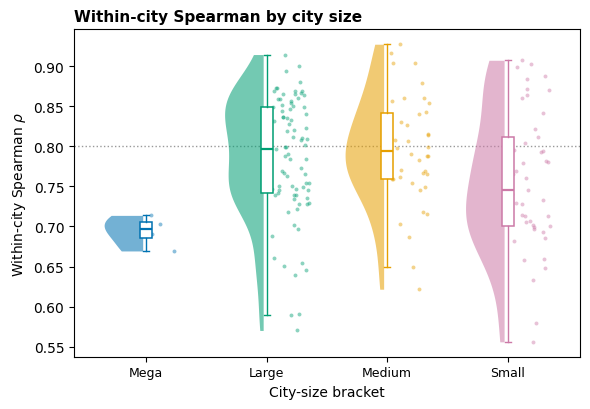

In [61]:
# --- Version 1: by city-size bracket (one cloud per bracket) ---
fig, ax = plt.subplots(figsize=(6.0, 4.2))

bracket_groups = [
    (BRACKET_LABELS[b], cells.loc[cells["bracket"] == b, "rho"].values, BRACKET_COLORS[b])
    for b in BRACKET_ORDER if (cells["bracket"] == b).any()
]
raincloud(ax, bracket_groups)
ax.axhline(0.80, color="0.6", linestyle=":", linewidth=1.0, zorder=0)
ax.set_ylabel(r"Within-city Spearman $\rho$")
ax.set_xlabel("City-size bracket")
ax.set_title("Within-city Spearman by city size", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()

out_fig = run_dir / "spearman_raincloud_by_city_size.pdf"
fig.savefig(out_fig, bbox_inches="tight")
fig.savefig(out_fig.with_suffix(".png"), dpi=200, bbox_inches="tight")
print(f"Wrote {out_fig}")
plt.show()


In [62]:
cells

,cbsa,cbsa_title,population,bracket,year,n,rho
119,36420,"Oklahoma City, OK",1445122,large,2010,100,0.868648
14,12940,"Baton Rouge, LA",871379,medium,2010,98,0.807989
0,10900,"Allentown-Bethlehem-Easton, PA-NJ",866764,medium,2010,100,0.783332
90,29540,"Lancaster, PA",555151,small,2010,100,0.768981
95,29820,"Las Vegas-Henderson-North Las Vegas, NV",2293764,large,2010,100,0.754534
...,...,...,...,...,...,...,...
89,29460,"Lakeland-Winter Haven, FL",760961,medium,2019,99,0.703182
51,16860,"Chattanooga, TN-GA",569333,small,2019,45,0.700464
174,45300,"Tampa-St. Petersburg-Clearwater, FL",3240469,large,2019,96,0.697274
94,29540,"Lancaster, PA",555151,small,2019,100,0.657791


Wrote C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\run_20260710\spearman_raincloud_by_year.pdf


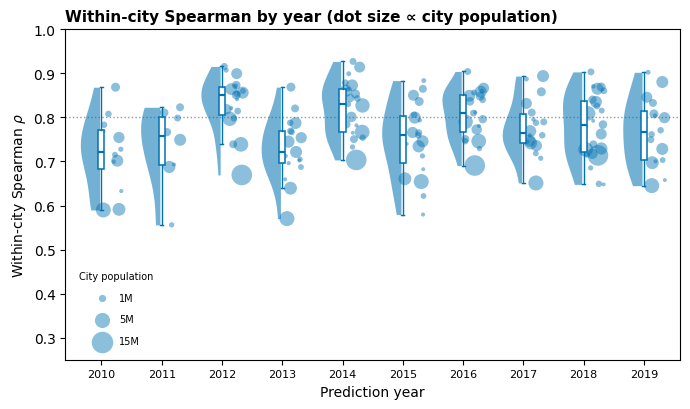

In [63]:
# --- Version 2: by prediction year (one cloud per year), dot size ~ city population ---
fig, ax = plt.subplots(figsize=(7.0, 4.2))

# Map population -> marker area, linear in sqrt(pop) so radius tracks population.
pop = cells["population"].astype(float)
smin, smax = 8.0, 220.0
p_lo, p_hi = np.sqrt(pop.min()), np.sqrt(pop.max())
scale = lambda p: smin + (smax - smin) * (np.sqrt(p) - p_lo) / max(p_hi - p_lo, 1e-9)

years_sorted = sorted(int(y) for y in cells["year"].unique())
year_groups, year_sizes = [], []
for yr in years_sorted:
    g = cells[cells["year"] == yr]
    year_groups.append((str(yr), g["rho"].values, YEAR_COLOR))
    year_sizes.append(scale(g["population"].astype(float).values))

raincloud(ax, year_groups, point_sizes=year_sizes)
ax.axhline(0.80, color="0.6", linestyle=":", linewidth=1.0, zorder=0)
ax.set_ylabel(r"Within-city Spearman $\rho$")
ax.set_xlabel("Prediction year")
ax.tick_params(axis="x", labelsize=8)
ax.set_title("Within-city Spearman by year (dot size ∝ city population)",
             loc="left", fontsize=11, fontweight="bold")
ax.set_ylim(0.25, 1.0)
# Population size legend (representative metro sizes).
legend_pops = [1_000_000, 5_000_000, 15_000_000]
handles = [
    ax.scatter([], [], s=scale(p), color=YEAR_COLOR, alpha=0.45, linewidths=0,
               label=f"{p/1e6:g}M")
    for p in legend_pops
]
ax.legend(handles=handles, title="City population", fontsize=7, title_fontsize=7,
          loc="lower left", frameon=True, facecolor="white", edgecolor="none",
          framealpha=0.85, labelspacing=1.2, borderpad=0.9)
fig.tight_layout()

out_fig = run_dir / "spearman_raincloud_by_year.pdf"
fig.savefig(out_fig, bbox_inches="tight")
fig.savefig(out_fig.with_suffix(".png"), dpi=200, bbox_inches="tight")
print(f"Wrote {out_fig}")
plt.show()
